In [1]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 

# Load Image

(np.float64(-0.5), np.float64(4319.5), np.float64(3239.5), np.float64(-0.5))

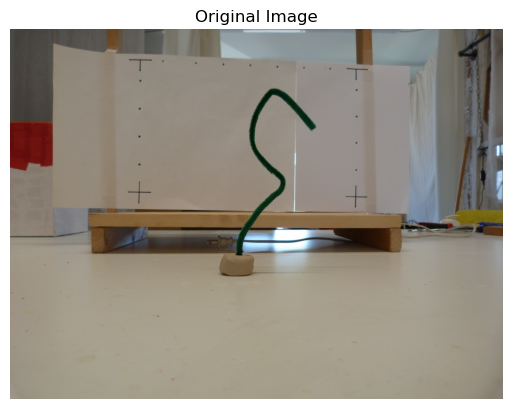

In [2]:
img = cv2.imread('test-images/camera2.JPG')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

# Preprocess for Perspective Correction

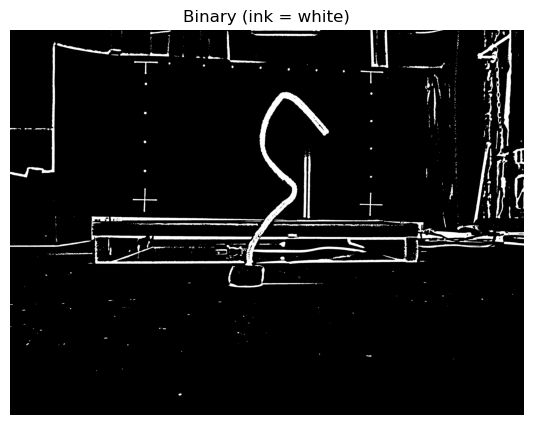

In [3]:

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# emphasize dark ink on white paper
blur = cv2.GaussianBlur(gray, (5,5), 0)
bin_inv = cv2.adaptiveThreshold(
    blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV,
    51, 7
)

# optional: remove small specks (dots) but keep big strokes
kernel = np.ones((3,3), np.uint8)
bin_inv = cv2.morphologyEx(bin_inv, cv2.MORPH_OPEN, kernel, iterations=1)

plt.figure(figsize=(10,5))
plt.imshow(bin_inv, cmap="gray")
plt.title("Binary (ink = white)")
plt.axis("off")
plt.show()


In [4]:
# Cross Detection by geometry 
num, labels, stats, centroids = cv2.connectedComponentsWithStats(bin_inv, connectivity=8)

cands = []
for i in range(1, num):
    x,y,w,h,area = stats[i]
    if area < 300:       # remove dots
        continue
    if area > 20000:     # remove huge blobs
        continue
    ar = w / max(h,1)
    if 0.4 < ar < 2.5:   # crosses roughly not extremely elongated
        cands.append(i)

centers = []
for i in cands:
    x,y,w,h,area = stats[i]
    roi = bin_inv[y:y+h, x:x+w]

    edges = cv2.Canny(roi, 50, 150)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=40,
                            minLineLength=min(w,h)//3, maxLineGap=10)
    if lines is None:
        continue

    # separate near-horizontal and near-vertical
    horiz, vert = [], []
    for l in lines[:,0]:
        x1,y1,x2,y2 = l
        dx, dy = x2-x1, y2-y1
        ang = np.arctan2(dy, dx)
        if abs(ang) < np.deg2rad(20):           # near horizontal
            horiz.append(l)
        if abs(abs(ang) - np.pi/2) < np.deg2rad(20):  # near vertical
            vert.append(l)

    if not horiz or not vert:
        continue

    # take longest line of each type
    def length(l):
        x1,y1,x2,y2 = l
        return (x2-x1)**2 + (y2-y1)**2

    lh = max(horiz, key=length)
    lv = max(vert, key=length)

    # compute intersection of the two infinite lines
    def line_params(l):
        x1,y1,x2,y2 = map(float,l)
        A = y2-y1
        B = x1-x2
        C = A*x1 + B*y1
        return A,B,C

    A1,B1,C1 = line_params(lh)
    A2,B2,C2 = line_params(lv)
    det = A1*B2 - A2*B1
    if abs(det) < 1e-6:
        continue
    ix = (B2*C1 - B1*C2)/det
    iy = (A1*C2 - A2*C1)/det

    centers.append((x+ix, y+iy))

centers = np.array(centers, dtype=np.float32)
print("Geometry centers:", centers)

Geometry centers: [[1145.       264.53983]
 [3035.7974   346.41684]
 [1127.8921  1423.2133 ]
 [3033.4324  1465.     ]]


In [5]:
def order_points(pts):
    # pts: (4,2)
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1).ravel()
    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(d)]
    bl = pts[np.argmax(d)]
    return np.array([tl, tr, br, bl], dtype=np.float32)

pts_src = order_points(centers)   # centers from A or B
print("Ordered src points:", pts_src)

Ordered src points: [[1145.       264.53983]
 [3035.7974   346.41684]
 [3033.4324  1465.     ]
 [1127.8921  1423.2133 ]]


In [20]:
# ---- define physical rectangle (with known dimensions) ----
W = 40.0   # cm 
H = 25.0   # cm 

# ---- choose resolution (pixels per cm) ----
ppcm = 30   # pixels per cm (adjust: 20–50 is typical)

width  = int(W * ppcm)
height = int(H * ppcm)

margin = 600 # pixel (tune for better visualization)


# ---- destination points (rectangular grid) ----
pts_dst = np.array([
    [margin, margin],               # top-left
    [width + margin, margin],       # top-right
    [width + margin, height + margin],  # bottom-right
    [margin, height + margin]       # bottom-left
], dtype=np.float32)

width_out  = width  + 2*margin
height_out = height + 2*margin

In [21]:
# Homography and Warp
H, _ = cv2.findHomography(pts_src, pts_dst)

img_rect = cv2.warpPerspective(img, H, (width_out, height_out))

# Green mask

(np.float64(-0.5), np.float64(2399.5), np.float64(1949.5), np.float64(-0.5))

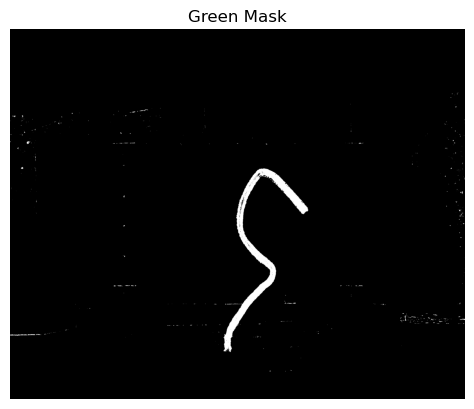

In [22]:
# Convert to HSV
hsv = cv2.cvtColor(img_rect, cv2.COLOR_BGR2HSV)

lower_green = np.array([30, 30, 20])
upper_green = np.array([80, 255, 255])
mask_green = cv2.inRange(hsv, lower_green, upper_green)

plt.imshow(mask_green, cmap='gray')
plt.title("Green Mask")
plt.axis('off')

# Clean the mask

(np.float64(-0.5), np.float64(2399.5), np.float64(1949.5), np.float64(-0.5))

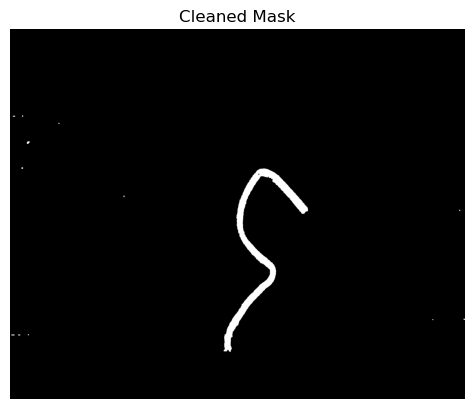

In [23]:
kernel = np.ones((5, 5), np.uint8)
mask_clean = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, kernel)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel)

plt.imshow(mask_clean, cmap='gray')
plt.title("Cleaned Mask")
plt.axis('off')

# Skeleton

In [24]:

from skimage.morphology import skeletonize

skel = skeletonize(mask_clean > 0)  

import networkx as nx

def skeleton_to_graph(ske, connectivity=2):
    ske = (ske > 0)
    pos = np.stack(np.where(ske))  # (2, N) -> rows, cols
    idx_img = -np.ones(ske.shape, dtype=int)
    idx_img[pos[0], pos[1]] = np.arange(pos.shape[1])

    if connectivity == 2:
        neigh = np.array([[0,1],[0,-1],[1,0],[-1,0],[1,1],[1,-1],[-1,1],[-1,-1]])
    else:
        neigh = np.array([[0,1],[0,-1],[1,0],[-1,0]])

    G = nx.Graph()
    for k in range(pos.shape[1]):
        r, c = pos[:, k]
        for dr, dc in neigh:
            rr, cc = r + dr, c + dc
            if rr < 0 or cc < 0 or rr >= ske.shape[0] or cc >= ske.shape[1]:
                continue
            if ske[rr, cc]:
                u = idx_img[r, c]
                v = idx_img[rr, cc]
                G.add_edge(u, v, weight=np.hypot(dr, dc))
    G.graph["rc"] = pos.T  # node index -> (row, col)
    return G

G = skeleton_to_graph(skel, connectivity=2)

rc = G.graph["rc"]  # (row, col) for each node index

deg = dict(G.degree())
endpoints = [n for n,d in deg.items() if d == 1]

# base = lowest point in image (largest row)
base = max(endpoints, key=lambda n: rc[n,0])

# pick farthest endpoint by geodesic distance from base
lengths = nx.single_source_dijkstra_path_length(G, base, weight="weight")
tip = max(endpoints, key=lambda n: lengths.get(n, -np.inf))

# ordered node list along the plant
path_nodes = nx.shortest_path(G, base, tip, weight="weight")  # [3](https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html)

# ordered pixel coordinates
rows = rc[path_nodes, 0].astype(float)
cols = rc[path_nodes, 1].astype(float)


# Calibration

In [25]:
h, w = mask_clean.shape

x_pix = cols - cols[0]
z_pix = (h - 1) - rows   # flip vertical axis

# physical units (cm)
x = x_pix / ppcm
z = z_pix / ppcm

plant_dist_to_camera = 30  # cm (adjust based on setup)
screen_dist_to_camera = 66 # cm (adjust based on setup)

lens_scale = plant_dist_to_camera / screen_dist_to_camera  # adjust for lens distortion (empirical)
x *= lens_scale
z *= lens_scale

# arc-length parameter s (cm)
dx = np.diff(x)
dz = np.diff(z)
ds = np.hypot(dx, dz)
s = np.concatenate([[0], np.cumsum(ds)])

In [26]:
from scipy.interpolate import interp1d

s_uniform = np.linspace(0, s[-1], 400)
x_u = interp1d(s, x, kind="linear")(s_uniform)
z_u = interp1d(s, z, kind="linear")(s_uniform)

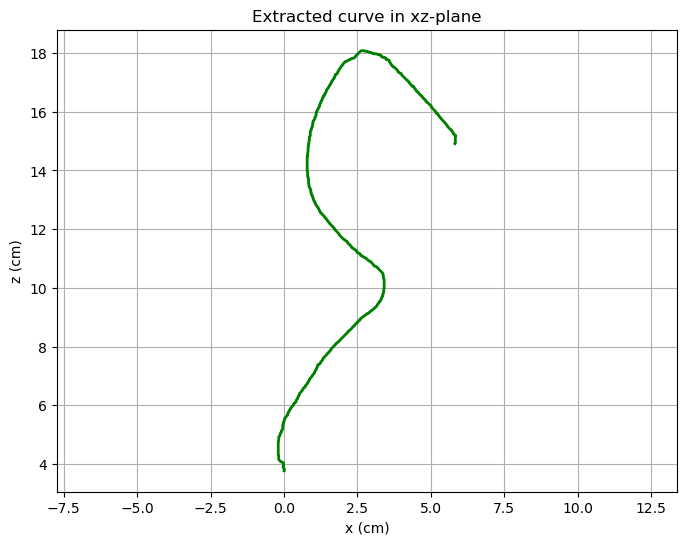

In [27]:
plt.figure(figsize=(8, 6))
plt.plot(x, z, 'g-', linewidth=2)
plt.xlabel('x (cm)')
plt.ylabel('z (cm)')
plt.title('Extracted curve in xz-plane')
plt.axis('equal')
plt.grid(True)
plt.show()